# Week 4: Baseline Model

In this notebook I train my first model, a plain linear regression, to set a baseline. My goal is not the best score yet. I think you need a simple honest starting point to measure every future model against. Whatever this scores becomes the number I try to beat with stronger models like XGBoost later.

## Setup and goal

I load the scikit learn tools for linear models, encoding, scaling, and the split. My plan is straightforward: train a linear regression, score it with R2 on the test set, and write the result down as my baseline.

In [3]:
### Goal: Train a Linear Regression as the first model.
## Evaluate using R² on the test set.
## Record baseline results.

import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, ElasticNet, Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

import matplotlib.pyplot as plt

le = LabelEncoder()




## Load the data and find the categorical columns

I load the train and test files I saved earlier and separate the features from the target, ClosePrice. I also drop dates and ID columns that are not real features. Then I look at which columns are text and split them into true categories versus simple yes/no flags, since those need different handling.

In [4]:
df_train = pd.read_csv('train_housing.csv')
df_test = pd.read_csv('test_housing.csv')
print (df_train.head(), df_test.head())
print (df_train.shape, df_test.shape)


drop_cols = [
    'ClosePrice',
    'CloseDate',
    'ListingContractDate',
    'PurchaseContractDate',
    'ContractStatusChangeDate',
    'ListingId',
    'ListingKey',
]

X_train = df_train.drop(columns=drop_cols, errors='ignore')
y_train = df_train['ClosePrice']

X_test = df_test.drop(columns=drop_cols, errors='ignore')
y_test = df_test['ClosePrice']


## check for categorical columns first

cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

bool_like = ['ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 
             'NewConstructionYN', 'FireplaceYN']

true_cat_cols = [col for col in cat_cols if col not in bool_like]

##distinguish boolean-like columns from true categorical columns
print(f"Boolean columns: {bool_like}")
print(f"True categorical columns: {true_cat_cols}")






  ViewYN PoolPrivateYN  OriginalListPrice  ListingKey   CloseDate  ClosePrice  \
0  False         False          1130000.0   538338723  2024-09-12   1090000.0   
1   True          True          1995000.0  1089077716  2024-09-30   1995000.0   
2   True          True          2340000.0  1089076111  2024-09-30   2340000.0   
3   True          True           984000.0  1089075731  2024-09-30    984000.0   
4   True         False          1250000.0  1089075621  2024-09-30   1225000.0   

    Latitude   Longitude PropertyType  LivingArea  ...  Levels  LotSizeArea  \
0  34.136660 -118.012799  Residential      2655.0  ...     One      14390.0   
1  33.804370 -116.439882  Residential      3524.0  ...     One      18295.0   
2  33.515988 -117.706900  Residential      2988.0  ...     Two      11900.0   
3  32.799141 -117.017206  Residential      1573.0  ...     One       6500.0   
4  34.024425 -117.136006  Residential      2889.0  ...     One       5338.0   

  MainLevelBedrooms NewConstructionYN 

/var/folders/_x/x2tsp53j6qnc79kydrrx_hkm0000gn/T/ipykernel_99239/3425802428.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()


## Encode the categorical columns

The problem is a linear model only understands numbers, not text. My solution is two steps: I map the yes/no flags to 1 and 0, and I use a label encoder on the true category columns. I fit the encoder on the train and test data together so it does not choke on a category it has never seen.

In [12]:


# boolean-like columns: map True/False to 1/0
# true categorical columns: use LabelEncoder to convert to numeric values
from sklearn.preprocessing import LabelEncoder


for col in bool_like:
    if col in X_train.columns:
        X_train[col] = X_train[col].map({True: 1, False: 1, 
                                          'True': 1, 'False': 0,
                                          '1': 1, '0': 0}).fillna(0)
        X_test[col] = X_test[col].map({True: 1, False: 1,
                                        'True': 1, 'False': 0,
                                        '1': 1, '0': 0}).fillna(0)

## Fit on combined train + test to capture all categories

le_dict = {}

for col in true_cat_cols:
    encoder = LabelEncoder()
    combined = pd.concat([X_train[col], X_test[col]]).astype(str).reset_index(drop=True)
    encoder.fit(combined)
    X_train[col] = encoder.transform(X_train[col].astype(str))
    X_test[col] = encoder.transform(X_test[col].astype(str))
    le_dict[col] = encoder

print("Encoding done!")
print(X_train.dtypes.value_counts())

print(f"Train date range: {df_train['CloseDate'].min()} → {df_train['CloseDate'].max()}")
print(f"Test date range:  {df_test['CloseDate'].min()} → {df_test['CloseDate'].max()}")
print(f"Train rows: {len(df_train):,}")
print(f"Test rows:  {len(df_test):,}")


Encoding done!
int64      18
float64    16
Name: count, dtype: int64
Train date range: 2024-08-01 → 2026-04-30
Test date range:  2026-05-01 → 2026-05-31
Train rows: 218,319
Test rows:  12,024


## Fill the remaining gaps

I drop any rows where the target price itself is missing, since I cannot learn from those. For the leftover missing features I use median imputation. I think the median is the safe choice for housing data, because prices and sizes are skewed and the median resists that.

In [6]:
from sklearn.impute import SimpleImputer

train_mask = y_train.notna()
X_train, y_train = X_train[train_mask], y_train[train_mask]

test_mask = y_test.notna()
X_test, y_test = X_test[test_mask], y_test[test_mask]

imputer = SimpleImputer(strategy="median")  # median is robust for housing data
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)


#get rid of NaN values in y_train and y_test

print(X_train.isna().sum())
print(X_test.isna().sum())
print(y_train.isna().sum(), y_test.isna().sum())


print(np.isnan(X_train_imp).sum())  # should be 0
print(np.isnan(X_test_imp).sum())


ViewYN                       0
PoolPrivateYN                0
OriginalListPrice          415
Latitude                    27
Longitude                   27
PropertyType                 0
LivingArea                 112
DaysOnMarket                 0
ListingKeyNumeric            0
MLSAreaMajor                 0
CountyOrParish               0
MlsStatus                    0
AttachedGarageYN             0
ParkingTotal                 2
PropertySubType              0
LotSizeAcres              3762
BuyerOfficeAOR               0
YearBuilt                  157
StreetNumberNumeric        255
BathroomsTotalInteger       27
City                         0
BedroomsTotal                0
FireplaceYN                  0
Stories                  25824
Levels                       0
LotSizeArea               3727
MainLevelBedrooms            0
NewConstructionYN            0
GarageSpaces              8377
HighSchoolDistrict           0
PostalCode                   0
AssociationFee               0
LotSizeS

## Scale and train

I scale the features so no single column dominates just because of its units, then I fit the linear regression and predict on the test set. I think scaling matters here, because sizes, counts, and fees all live on very different ranges.

In [7]:
# scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

## Evaluate the baseline

I score the model with R2, RMSE, MAPE, and median APE so I can see accuracy from a few angles. The baseline lands around an R2 of 0.34 with a high percent error. I think that is fine for a first pass: it is weak, but it is the honest floor I now try to beat.

In [19]:
#evaluate the model using R² on the test set
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

r2_log = r2_score(y_test, y_pred)
mae_log = mean_absolute_error(y_test, y_pred)
## rmse_log = np.sqrt(mean_squared_error(y_test, y_pred))
ape_log = np.abs((y_test - y_pred) / y_test)
mape_log = ape_log.mean() * 100
mdape_log = np.median(ape_log) * 100

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print("Linear Regression Results")
print(f"R²:    {r2:.4f}")
print(f"RMSE:  ${rmse:,.2f}")
print(f"MAPE:  {mape:.2f}%")
print(f"MdAPE: {mdape:.2f}%")

print(f"\nLog-R²:    {r2_log:f}")
print(f"Log-MAE:   {mae_log:,f}")
print(f"RMSE:  {rmse_log:,f}")
print(f"Log-MAPE:  {mape_log:f}%")
print(f"Log-MdAPE: {mdape_log:f}%")

Linear Regression Results
R²:    0.3397
RMSE:  $1,363,592.71
MAPE:  55.94%
MdAPE: 33.60%

Log-R²:    0.339680
Log-MAE:   537,851.409627
RMSE:  1,363,592.705674
Log-MAPE:  55.940677%
Log-MdAPE: 33.597438%


## Plot predictions vs actual

I plot predicted price against actual price, with a diagonal line for a perfect prediction. I zoom into the bulk of the data and ignore the top one percent, so the outliers do not squash the view. The spread around the line shows how much room there is to improve.

Text(0, 0.5, 'Predicted ClosePrice')

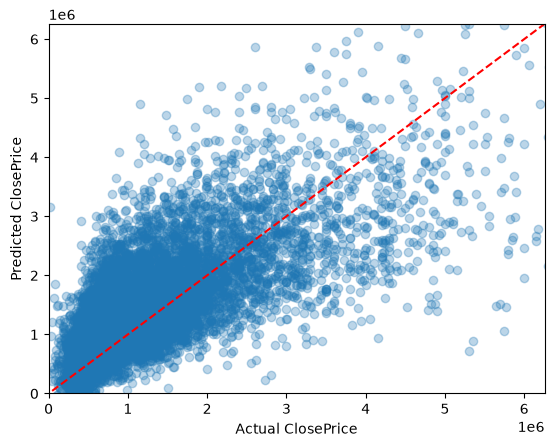

In [15]:
plt.scatter(y_test, y_pred, alpha=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')

# zoom to where most of the data actually is
upper = np.percentile(y_test, 99)   # ignore the top 1% outliers
plt.xlim(0, upper)
plt.ylim(0, upper)
plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")

## Save the model

I save the trained model and the scaler with joblib. I think saving the scaler next to the model matters, because I need the exact same scaling to reuse the model later.

In [10]:
import joblib

joblib.dump(model, 'linear_regression_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model saved!")

Model saved!
